# 🧠 Brain Tumor MRI Classification
## Deep Learning para Classificação Binária: Normal vs Tumor

**Autor:** Seu Nome  
**Dataset:** Brain MRI Images for Brain Tumor Detection (Kaggle)  
**Framework:** TensorFlow/Keras  
**Ambiente:** Google Colab (GPU T4)

---

### Por que TensorFlow/Keras?
- Melhor integração com o ecossistema Google (Colab, TFX, TF-Lite)
- API de alto nível (Keras) facilita prototipagem rápida
- Suporte nativo a callbacks como EarlyStopping e ModelCheckpoint
- Keras Applications oferece modelos pré-treinados (ResNet, EfficientNet) de forma simples
- TensorBoard integrado para visualização em tempo real

### Estrutura do Notebook
1. Setup e instalação
2. Download do dataset via Kaggle API
3. EDA (Análise Exploratória)
4. Pré-processamento
5. **Baseline: CNN simples**
6. **Modelo Avançado: EfficientNetB3 com Transfer Learning**
7. Comparação de modelos
8. Interpretabilidade com Grad-CAM
9. Discussão clínica


## 1. Setup e Instalação

In [1]:
# ── Instalar dependências extras ──────────────────────────────────────────────
!pip install -q kaggle opencv-python-headless scikit-learn matplotlib seaborn
!pip install -q grad-cam  # pytorch-grad-cam para visualização

import os, sys, random, warnings, json, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB3, ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)

warnings.filterwarnings('ignore')

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponível: {tf.config.list_physical_devices("GPU")}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 39.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
TensorFlow: 2.19.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download do Dataset via Kaggle API

In [3]:
# ── Configurar Kaggle API ─────────────────────────────────────────────────────
# OPÇÃO 1: Upload manual do kaggle.json
# from google.colab import files

print('📁 Faça upload do seu kaggle.json')
print('   Obtenha em: https://www.kaggle.com/settings > API > Create New Token')
# uploaded = files.upload()  # Descomente para fazer upload interativo

# OPÇÃO 2: Via Google Drive (recomendado para uso recorrente)
# from google.colab import drive
# drive.mount('/content/drive')
# !cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

# Configurar permissões
!mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# ── Download do Dataset ───────────────────────────────────────────────────────
# Dataset: Brain MRI Images for Brain Tumor Detection
# https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection

DATA_DIR = Path('/content/data')
DATA_DIR.mkdir(exist_ok=True)

!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection \
    -p /content/data --unzip

# Verificar estrutura
for p in sorted(DATA_DIR.rglob('*'))[:20]:
    print(p)

📁 Faça upload do seu kaggle.json
   Obtenha em: https://www.kaggle.com/settings > API > Create New Token
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
100% 15.1M/15.1M [00:00<00:00, 138MB/s]

/content/data/brain_tumor_dataset
/content/data/brain_tumor_dataset/no
/content/data/brain_tumor_dataset/no/1 no.jpeg
/content/data/brain_tumor_dataset/no/10 no.jpg
/content/data/brain_tumor_dataset/no/11 no.jpg
/content/data/brain_tumor_dataset/no/12 no.jpg
/content/data/brain_tumor_dataset/no/13 no.jpg
/content/data/brain_tumor_dataset/no/14 no.jpg
/content/data/brain_tumor_dataset/no/15 no.jpg
/content/data/brain_tumor_dataset/no/17 no.jpg
/content/data/brain_tumor_dataset/no/18 no.jpg
/content/data/brain_tumor_dataset/no/19 no.jpg
/content/data/brain_tumor_dataset/no/2 no.jpeg
/content/data/brain_tumor_dataset/no/20 no.jpg
/content/data/br

In [4]:
# ── Organizar estrutura de diretórios ─────────────────────────────────────────
# O dataset navoneel tem: yes/ (tumor) e no/ (normal)

RAW_YES = DATA_DIR / 'brain_tumor_dataset' / 'yes'  # com tumor
RAW_NO  = DATA_DIR / 'brain_tumor_dataset' / 'no'   # normal

# Caso a estrutura seja diferente, adaptar aqui:
if not RAW_YES.exists():
    # Busca automática por subpastas
    all_dirs = [d for d in DATA_DIR.rglob('*') if d.is_dir()]
    print('Subpastas encontradas:', all_dirs)

# Coletar todos os caminhos de imagens com labels
image_paths, labels = [], []

for img_path in RAW_YES.glob('*.jpg'):
    image_paths.append(str(img_path))
    labels.append(1)  # tumor

for img_path in RAW_NO.glob('*.jpg'):
    image_paths.append(str(img_path))
    labels.append(0)  # normal

df = pd.DataFrame({'path': image_paths, 'label': labels,
                   'class': ['tumor' if l==1 else 'normal' for l in labels]})

print(f'Total de imagens: {len(df)}')
print(df['class'].value_counts())


Total de imagens: 171
class
tumor     86
normal    85
Name: count, dtype: int64


## 3. Análise Exploratória dos Dados (EDA)

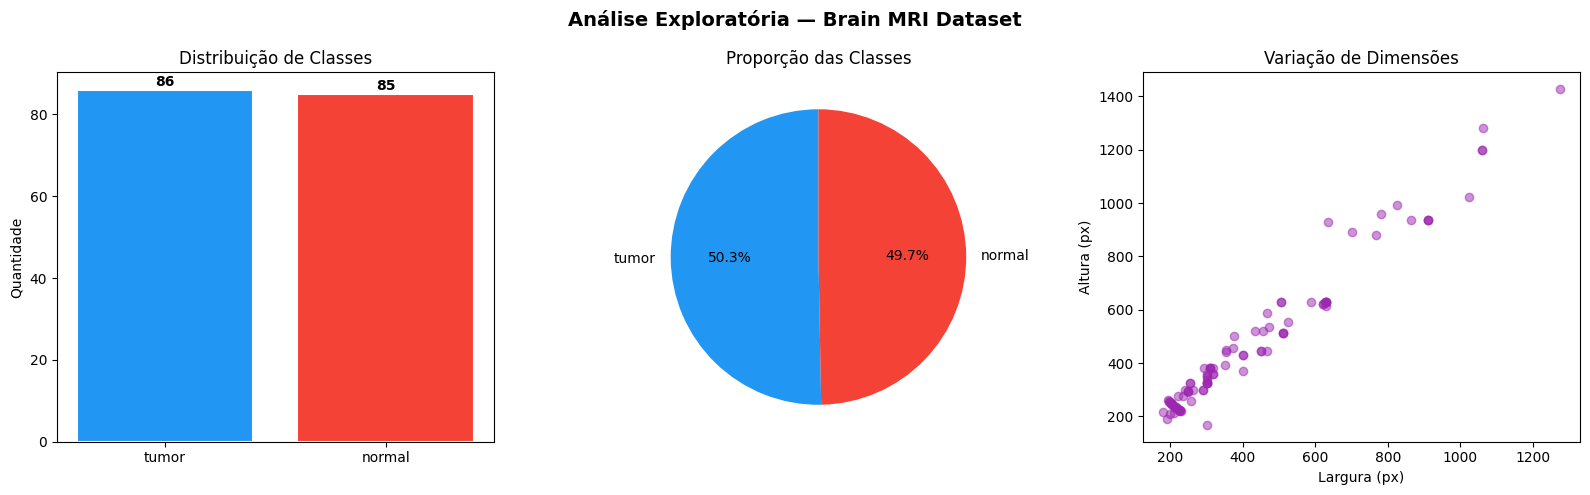

Dimensões — Largura: 415±245 | Altura: 460±273


In [5]:
# ── Distribuição das classes ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análise Exploratória — Brain MRI Dataset', fontsize=14, fontweight='bold')

# Contagem de classes
counts = df['class'].value_counts()
colors = ['#2196F3', '#F44336']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição de Classes')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pizza
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção das Classes')

# Dimensões das imagens
widths, heights = [], []
for path in df['path'][:100]:  # amostra
    img = cv2.imread(path)
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

axes[2].scatter(widths, heights, alpha=0.5, color='#9C27B0')
axes[2].set_xlabel('Largura (px)')
axes[2].set_ylabel('Altura (px)')
axes[2].set_title('Variação de Dimensões')

plt.tight_layout()
plt.savefig('/content/eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dimensões — Largura: {np.mean(widths):.0f}±{np.std(widths):.0f} | Altura: {np.mean(heights):.0f}±{np.std(heights):.0f}')


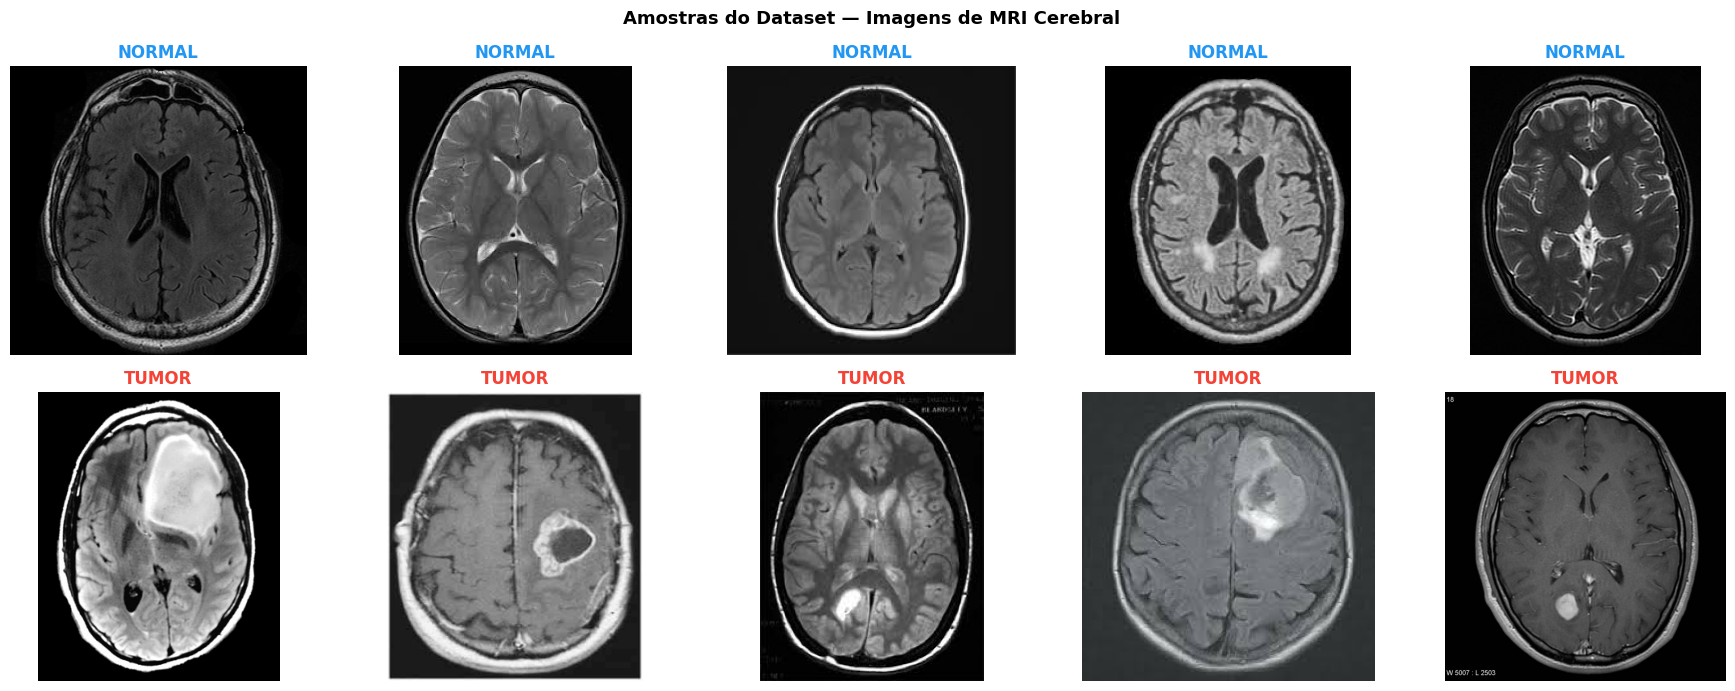

In [6]:
# ── Visualizar amostras das classes ──────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Amostras do Dataset — Imagens de MRI Cerebral', fontsize=13, fontweight='bold')

for i, cls in enumerate(['normal', 'tumor']):
    samples = df[df['class'] == cls].sample(5, random_state=SEED)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].set_title(f'{cls.upper()}', color=colors[i], fontweight='bold')
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('/content/eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()


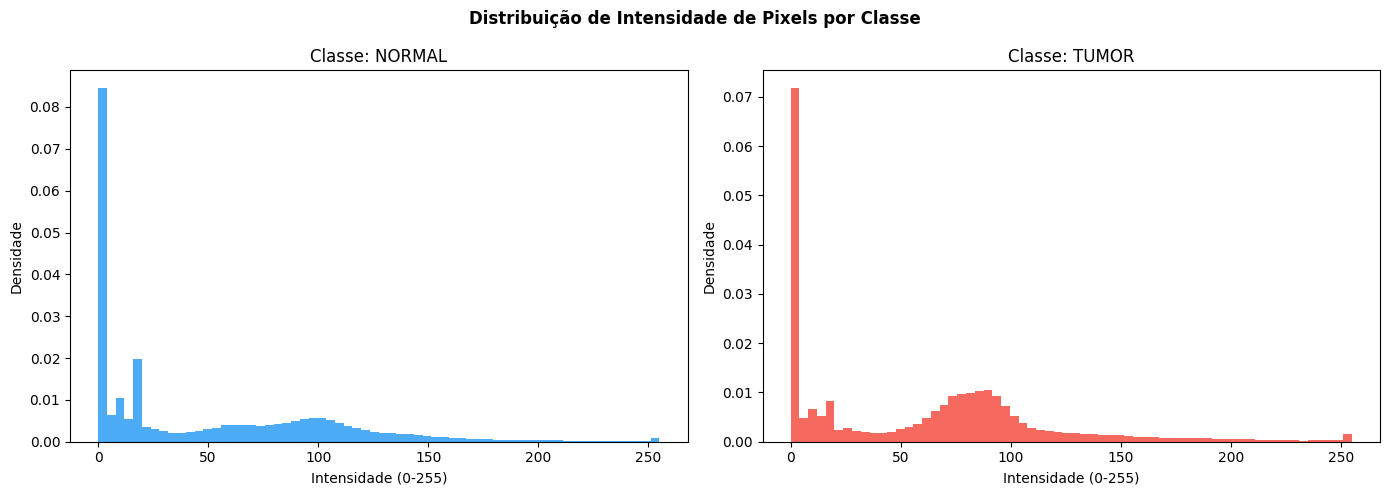

In [7]:
# ── Análise de intensidade de pixels ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de Intensidade de Pixels por Classe', fontweight='bold')

for idx, (cls, color) in enumerate([('normal', '#2196F3'), ('tumor', '#F44336')]):
    sample_paths = df[df['class'] == cls]['path'].sample(30, random_state=SEED)
    all_pixels = []
    for path in sample_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            all_pixels.extend(img.flatten())
    axes[idx].hist(all_pixels, bins=64, color=color, alpha=0.8, density=True)
    axes[idx].set_title(f'Classe: {cls.upper()}')
    axes[idx].set_xlabel('Intensidade (0-255)')
    axes[idx].set_ylabel('Densidade')

plt.tight_layout()
plt.savefig('/content/eda_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Pré-processamento e Divisão dos Dados

In [8]:
# ── Configurações globais ─────────────────────────────────────────────────────
IMG_SIZE    = 224        # Padrão ImageNet (compatível com EfficientNet/ResNet)
BATCH_SIZE  = 32
EPOCHS_BASE = 30         # Baseline
EPOCHS_ADV  = 50         # Modelo avançado

# ── Divisão Holdout 70-30 ──────────────────────────────────────────────────────
# Estratificada para manter proporção entre classes
X = df['path'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Subdivide treino em treino/validação (80/20 do treino = 56%/14% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=SEED, stratify=y_train
)

print(f'DIVISÃO HOLDOUT (70/30 com validação interna):')
print(f'  Treino:    {len(X_train):>5} imagens  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validação: {len(X_val):>5} imagens  ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Teste:     {len(X_test):>5} imagens  ({len(X_test)/len(X)*100:.1f}%)')
print()
print(f'Distribuição no treino — Normal: {(y_train==0).sum()} | Tumor: {(y_train==1).sum()}')
print(f'Distribuição no teste  — Normal: {(y_test==0).sum()}  | Tumor: {(y_test==1).sum()}')


DIVISÃO HOLDOUT (70/30 com validação interna):
  Treino:       95 imagens  (55.6%)
  Validação:    24 imagens  (14.0%)
  Teste:        52 imagens  (30.4%)

Distribuição no treino — Normal: 47 | Tumor: 48
Distribuição no teste  — Normal: 26  | Tumor: 26


In [10]:
# ── Funções de carregamento e pré-processamento ───────────────────────────────
def load_and_preprocess(path, label, img_size=IMG_SIZE, augment=False, rotation_layer=None):
    """
    Carrega imagem, normaliza e opcionalmente aplica augmentation.
    Retorna tensor (img_size, img_size, 3) com valores [0,1].
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.cast(img, tf.float32) / 255.0  # Normalização [0,1]

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
        # Rotação aleatória pequena (±15°)
        if rotation_layer:
            img = rotation_layer(img)

    return img, label


def build_dataset(paths, labels, augment=False, shuffle=False):
    """Constrói tf.data.Dataset otimizado com prefetch."""
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    # Instantiate the RandomRotation layer once if augmentation is enabled
    rotation_layer = None
    if augment:
        rotation_layer = tf.keras.layers.RandomRotation(0.042)

    ds = ds.map(
        lambda p, l: load_and_preprocess(p, l, augment=augment, rotation_layer=rotation_layer),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


# Criar datasets
train_ds = build_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = build_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = build_dataset(X_test,  y_test,  augment=False, shuffle=False)

print('Datasets criados com sucesso!')
print(f'Batches por epoch (treino): {len(train_ds)}')


Datasets criados com sucesso!
Batches por epoch (treino): 3


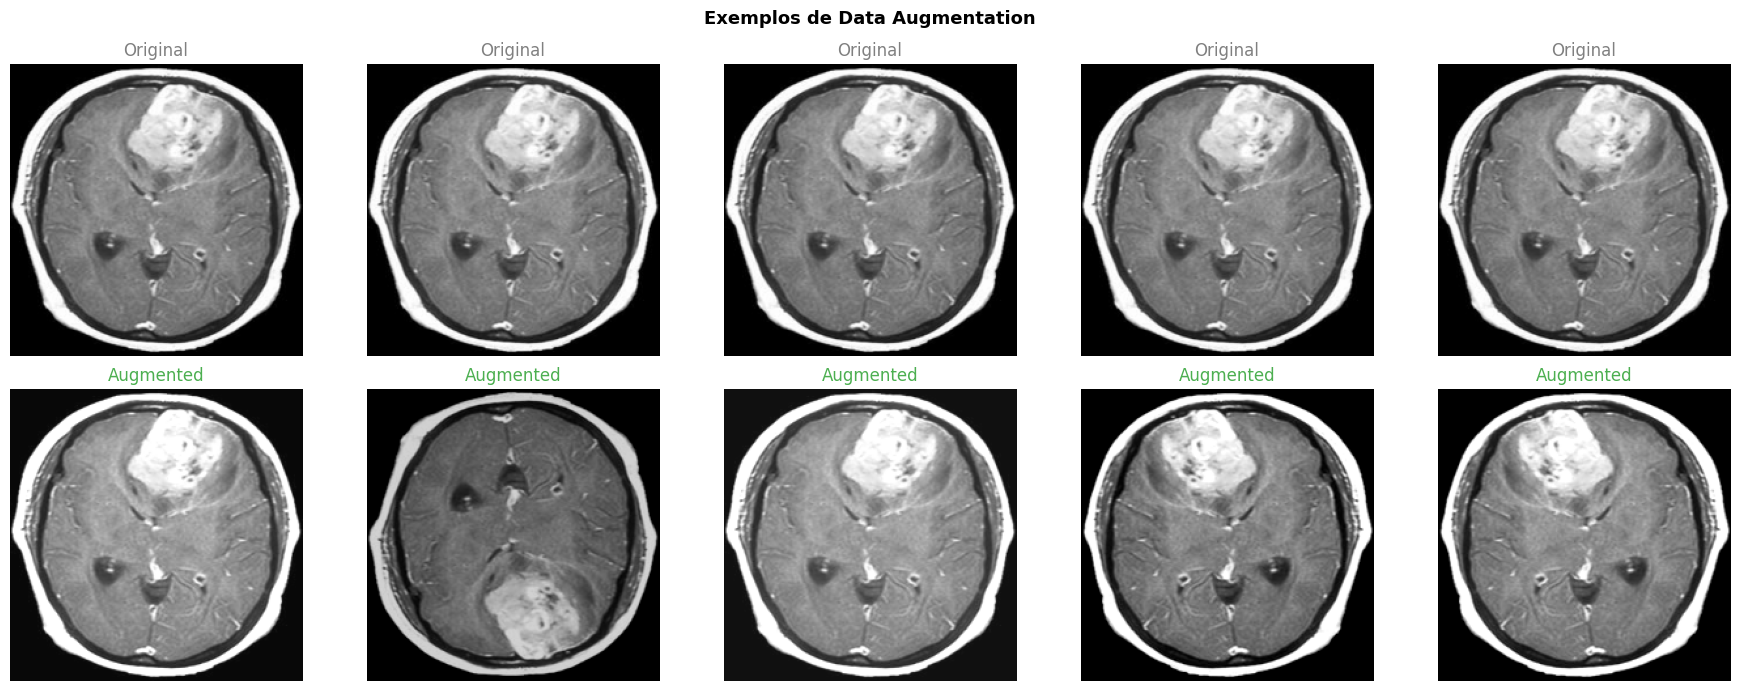

In [11]:
# ── Visualizar augmentation ───────────────────────────────────────────────────
sample_path = X_train[0]
sample_label = y_train[0]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Exemplos de Data Augmentation', fontsize=13, fontweight='bold')

# Original
orig, _ = load_and_preprocess(sample_path, sample_label, augment=False)
for j in range(5):
    axes[0, j].imshow(orig.numpy())
    axes[0, j].set_title('Original', color='gray')
    axes[0, j].axis('off')

# Augmented
for j in range(5):
    aug, _ = load_and_preprocess(sample_path, sample_label, augment=True)
    axes[1, j].imshow(aug.numpy())
    axes[1, j].set_title('Augmented', color='#4CAF50')
    axes[1, j].axis('off')

plt.tight_layout()
plt.savefig('/content/augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Modelo Baseline — CNN Simples

Arquitetura simplificada com 3 blocos convolucionais para servir como referência.

In [12]:
# ── Callbacks compartilhados ──────────────────────────────────────────────────
def get_callbacks(model_name, patience_es=8, patience_lr=4):
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=patience_es,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'/content/models/{model_name}_best.h5',
            monitor='val_auc', mode='max',
            save_best_only=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=patience_lr, min_lr=1e-7, verbose=1
        ),
        callbacks.TensorBoard(log_dir=f'/content/logs/{model_name}')
    ]

os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/logs',   exist_ok=True)


# ── Arquitetura Baseline ──────────────────────────────────────────────────────
def build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """
    CNN simples com 3 blocos Conv-BN-Pool.
    Parâmetros: ~2M  |  Propósito: baseline de referência
    """
    model = models.Sequential([
        # Bloco 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1_1'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1_2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Bloco 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Bloco 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.40),

        # Classificador
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.50),
        layers.Dense(1, activation='sigmoid', name='output')  # binário
    ], name='baseline_cnn')

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model


baseline = build_baseline_cnn()
baseline.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,985 (679.63 KB)

 Trainable params: 173,345 (677.13 KB)

 Non-trainable params: 640 (2.50 KB)

In [13]:
# ── Treinar Baseline ──────────────────────────────────────────────────────────
print('=' * 60)
print('TREINANDO MODELO BASELINE (CNN Simples)')
print('=' * 60)

history_baseline = baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASE,
    callbacks=get_callbacks('baseline'),
    verbose=1
)


TREINANDO MODELO BASELINE (CNN Simples)
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5192 - auc: 0.6258 - loss: 0.7284 - precision: 0.5152 - recall: 0.6426   
Epoch 1: val_auc improved from None to 0.67708, saving model to /content/models/baseline_best.h5



Epoch 1: finished saving model to /content/models/baseline_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 44s 10s/step - accuracy: 0.5263 - auc: 0.6155 - loss: 0.7487 - precision: 0.5283 - recall: 0.5833 - val_accuracy: 0.7083 - val_auc: 0.6771 - val_loss: 0.6904 - val_precision: 0.6923 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.6378 - auc: 0.6592 - loss: 0.7354 - precision: 0.6385 - recall: 0.6592
Epoch 2: val_auc improved from 0.67708 to 0.68750, saving model to /content/models/baseline_best.h5



Epoch 2: finished saving model to /content/models/baseline_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 380ms/step - accuracy: 0.6947 - auc: 0.7212 - loss: 0.6608 - precision: 0.6727 - recall: 0.7708 - val_accuracy: 0.6250 - val_auc: 0.6875 - val_loss: 0.6905 - val_precision: 0.5882 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.6533 - auc: 0.6970 - loss: 0.7481 - precision: 0.5833 - recall: 0.7593
Epoch 3: val_auc did not improve from 0.68750
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 335ms/step - accuracy: 0.6632 - auc: 0.6933 - loss: 0.7154 - precision: 0.6667 - recall: 0.6667 - val_accuracy: 0.5833 - val_auc: 0.6875 - val_loss: 0.6910 - val_precision: 0.5500 - val_recall: 0.9167 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.7073 - auc: 0.7308 - loss: 0.6236 - precision: 0.7823 - recall: 0.6157
Epoch 4: val_auc did not improve from 0.68750
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.7158 - auc:


Epoch 5: finished saving model to /content/models/baseline_best.h5

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 377ms/step - accuracy: 0.7684 - auc: 0.8391 - loss: 0.4876 - precision: 0.7600 - recall: 0.7917 - val_accuracy: 0.5833 - val_auc: 0.6979 - val_loss: 0.6906 - val_precision: 0.5625 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.7385 - auc: 0.8096 - loss: 0.5406 - precision: 0.7197 - recall: 0.7775
Epoch 6: val_auc did not improve from 0.69792
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 347ms/step - accuracy: 0.6842 - auc: 0.7644 - loss: 0.5824 - precision: 0.6800 - recall: 0.7083 - val_accuracy: 0.6250 - val_auc: 0.6979 - val_loss: 0.6899 - val_precision: 0.5882 - val_recall: 0.8333 - learning_rate: 5.0000e-04
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.7926 - auc: 0.8482 - loss: 0.5006 - precision: 0.7905 - recall: 0.8285
Epoch 7: val_auc did not impr


Epoch 8: finished saving model to /content/models/baseline_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 384ms/step - accuracy: 0.7474 - auc: 0.7846 - loss: 0.5629 - precision: 0.7308 - recall: 0.7917 - val_accuracy: 0.6250 - val_auc: 0.7361 - val_loss: 0.6894 - val_precision: 0.5789 - val_recall: 0.9167 - learning_rate: 5.0000e-04
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.7577 - auc: 0.8659 - loss: 0.4657 - precision: 0.7603 - recall: 0.7941
Epoch 9: val_auc did not improve from 0.73611
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.7263 - auc: 0.8227 - loss: 0.5196 - precision: 0.7200 - recall: 0.7500 - val_accuracy: 0.6250 - val_auc: 0.7292 - val_loss: 0.6898 - val_precision: 0.6667 - val_recall: 0.5000 - learning_rate: 5.0000e-04
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.7979 - auc: 0.8035 - loss: 0.5355 - precision: 0.7892 - recall: 0.8368
Epoch 10: val_auc did not improve from 0.73611
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step - accuracy: 0.8


Epoch 12: finished saving model to /content/models/baseline_best.h5

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step - accuracy: 0.7158 - auc: 0.7928 - loss: 0.5591 - precision: 0.7059 - recall: 0.7500 - val_accuracy: 0.5000 - val_auc: 0.7604 - val_loss: 0.6913 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 13/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.7058 - auc: 0.7655 - loss: 0.5655 - precision: 0.7300 - recall: 0.6752
Epoch 13: val_auc did not improve from 0.76042
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - accuracy: 0.7579 - auc: 0.8298 - loss: 0.5018 - precision: 0.7660 - recall: 0.7500 - val_accuracy: 0.5000 - val_auc: 0.7326 - val_loss: 0.6918 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 14/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.7752 - auc: 0.7841 - loss: 0.5641 - precision: 0.7260 - recall: 0.8659
Epoc


Epoch 15: finished saving model to /content/models/baseline_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 390ms/step - accuracy: 0.7789 - auc: 0.8617 - loss: 0.4613 - precision: 0.7547 - recall: 0.8333 - val_accuracy: 0.5000 - val_auc: 0.8056 - val_loss: 0.6909 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 16/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.6656 - auc: 0.7612 - loss: 0.5776 - precision: 0.6715 - recall: 0.6810
Epoch 16: val_auc did not improve from 0.80556

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step - accuracy: 0.6842 - auc: 0.7890 - loss: 0.5378 - precision: 0.6800 - recall: 0.7083 - val_accuracy: 0.5000 - val_auc: 0.7882 - val_loss: 0.6903 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 8.


## 6. Modelo Avançado — EfficientNetB3 com Transfer Learning

Estratégia em **2 fases**: (1) treinar apenas o classificador com backbone congelado, (2) fine-tuning das últimas camadas.

In [14]:
# ── Arquitetura Avançada com Transfer Learning ────────────────────────────────
def build_advanced_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), unfreeze_layers=30):
    """
    EfficientNetB3 pré-treinado em ImageNet.
    Fase 1: backbone congelado — treina apenas o head classificador
    Fase 2: fine-tuning das últimas `unfreeze_layers` camadas

    Justificativa do EfficientNetB3 vs ResNet50:
    - Melhor acurácia/parâmetro (compound scaling)
    - Menor overfitting em datasets pequenos
    - Comprovado em literatura de imagens médicas (Tan & Le, 2019)
    """
    inputs = layers.Input(shape=input_shape)

    # Pré-processamento específico do EfficientNet
    x = tf.keras.applications.efficientnet.preprocess_input(inputs * 255.0)

    # Backbone pré-treinado
    backbone = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        pooling=None
    )
    backbone.trainable = False  # Fase 1: congelado

    # Head classificador
    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='efficientnet_b3_transfer')
    return model, backbone


advanced, backbone_ref = build_advanced_model()

advanced.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print(f'Parâmetros treináveis (fase 1): {advanced.count_params():,}')


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parâmetros treináveis (fase 1): 11,579,184


In [15]:
# ── Fase 1: Treinar apenas o head ─────────────────────────────────────────────
print('FASE 1: Treinando apenas o classificador (backbone congelado)')

history_adv_phase1 = advanced.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=get_callbacks('advanced_phase1'),
    verbose=1
)


FASE 1: Treinando apenas o classificador (backbone congelado)
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.5423 - auc: 0.5700 - loss: 0.9997 - precision: 0.5741 - recall: 0.5196 
Epoch 1: val_auc improved from None to 0.90972, saving model to /content/models/advanced_phase1_best.h5



Epoch 1: finished saving model to /content/models/advanced_phase1_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 98s 25s/step - accuracy: 0.6737 - auc: 0.7533 - loss: 0.7847 - precision: 0.6809 - recall: 0.6667 - val_accuracy: 0.7500 - val_auc: 0.9097 - val_loss: 0.5757 - val_precision: 0.8750 - val_recall: 0.5833 - learning_rate: 0.0010
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.7980 - auc: 0.8800 - loss: 0.7001 - precision: 0.8139 - recall: 0.7974
Epoch 2: val_auc improved from 0.90972 to 0.93056, saving model to /content/models/advanced_phase1_best.h5



Epoch 2: finished saving model to /content/models/advanced_phase1_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 758ms/step - accuracy: 0.8316 - auc: 0.9091 - loss: 0.5887 - precision: 0.8333 - recall: 0.8333 - val_accuracy: 0.7500 - val_auc: 0.9306 - val_loss: 0.5000 - val_precision: 0.8750 - val_recall: 0.5833 - learning_rate: 0.0010
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8606 - auc: 0.9578 - loss: 0.4032 - precision: 0.8394 - recall: 0.8816
Epoch 3: val_auc did not improve from 0.93056
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step - accuracy: 0.8632 - auc: 0.9504 - loss: 0.4376 - precision: 0.8571 - recall: 0.8750 - val_accuracy: 0.8333 - val_auc: 0.9306 - val_loss: 0.4639 - val_precision: 0.9000 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9094 - auc: 0.9557 - loss: 0.3842 - precision: 0.9176 - recall: 0.9127
Epoch 4: val_auc improved from 0.93056 to 0.93750, saving model to /content/models/advanced_phase1_best


Epoch 4: finished saving model to /content/models/advanced_phase1_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 669ms/step - accuracy: 0.9158 - auc: 0.9628 - loss: 0.3539 - precision: 0.9000 - recall: 0.9375 - val_accuracy: 0.7917 - val_auc: 0.9375 - val_loss: 0.4641 - val_precision: 0.8182 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8781 - auc: 0.9680 - loss: 0.3742 - precision: 0.9007 - recall: 0.8578
Epoch 5: val_auc improved from 0.93750 to 0.94097, saving model to /content/models/advanced_phase1_best.h5



Epoch 5: finished saving model to /content/models/advanced_phase1_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 962ms/step - accuracy: 0.8842 - auc: 0.9608 - loss: 0.3881 - precision: 0.8936 - recall: 0.8750 - val_accuracy: 0.7917 - val_auc: 0.9410 - val_loss: 0.4500 - val_precision: 0.8182 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9512 - auc: 0.9807 - loss: 0.3081 - precision: 0.9124 - recall: 0.9931
Epoch 6: val_auc did not improve from 0.94097
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step - accuracy: 0.9474 - auc: 0.9741 - loss: 0.3243 - precision: 0.9216 - recall: 0.9792 - val_accuracy: 0.8333 - val_auc: 0.9375 - val_loss: 0.4245 - val_precision: 0.8333 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9059 - auc: 0.9827 - loss: 0.3178 - precision: 0.8764 - recall: 0.9177
Epoch 7: val_auc improved from 0.94097 to 0.95139, saving model to /content/models/advanced_phase1_best


Epoch 7: finished saving model to /content/models/advanced_phase1_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 778ms/step - accuracy: 0.9053 - auc: 0.9792 - loss: 0.3041 - precision: 0.9149 - recall: 0.8958 - val_accuracy: 0.8333 - val_auc: 0.9514 - val_loss: 0.3971 - val_precision: 0.8333 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9268 - auc: 0.9905 - loss: 0.2045 - precision: 0.9319 - recall: 0.9332
Epoch 8: val_auc improved from 0.95139 to 0.95139, saving model to /content/models/advanced_phase1_best.h5



Epoch 8: finished saving model to /content/models/advanced_phase1_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 746ms/step - accuracy: 0.9053 - auc: 0.9814 - loss: 0.2918 - precision: 0.8824 - recall: 0.9375 - val_accuracy: 0.8333 - val_auc: 0.9514 - val_loss: 0.3780 - val_precision: 0.8333 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 9/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9564 - auc: 0.9832 - loss: 0.2475 - precision: 0.9573 - recall: 0.9500
Epoch 9: val_auc did not improve from 0.95139
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.9474 - auc: 0.9696 - loss: 0.3249 - precision: 0.9778 - recall: 0.9167 - val_accuracy: 0.8333 - val_auc: 0.9514 - val_loss: 0.3801 - val_precision: 0.8333 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 10/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9425 - auc: 0.9849 - loss: 0.2075 - precision: 0.9748 - recall: 0.9092
Epoch 10: val_auc did not improve from 0.95139
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step - accuracy: 0.93


Epoch 11: finished saving model to /content/models/advanced_phase1_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 695ms/step - accuracy: 0.9684 - auc: 1.0000 - loss: 0.1347 - precision: 1.0000 - recall: 0.9375 - val_accuracy: 0.7917 - val_auc: 0.9514 - val_loss: 0.3821 - val_precision: 0.7692 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 12/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9737 - auc: 0.9968 - loss: 0.1456 - precision: 0.9855 - recall: 0.9618
Epoch 12: val_auc did not improve from 0.95139

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 382ms/step - accuracy: 0.9368 - auc: 0.9905 - loss: 0.2303 - precision: 0.9565 - recall: 0.9167 - val_accuracy: 0.7917 - val_auc: 0.9514 - val_loss: 0.3842 - val_precision: 0.7692 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 13/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9459 - auc: 0.9761 - loss: 0.3138 - precision: 0.9262 - recall: 0.9594
Epoch 13: val_auc did

In [16]:
# ── Fase 2: Fine-tuning das últimas camadas ───────────────────────────────────
print('FASE 2: Fine-tuning das últimas 30 camadas do backbone')

# Descongela as últimas N camadas
backbone_ref.trainable = True
for layer in backbone_ref.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in backbone_ref.layers if l.trainable)
print(f'Camadas treináveis no backbone: {trainable_count}/{len(backbone_ref.layers)}')

# LR menor para fine-tuning (evita destruir pesos pré-treinados)
advanced.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

history_adv_phase2 = advanced.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_ADV,
    callbacks=get_callbacks('advanced_phase2', patience_es=10),
    verbose=1
)


FASE 2: Fine-tuning das últimas 30 camadas do backbone
Camadas treináveis no backbone: 30/385
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7875 - auc: 0.8599 - loss: 0.6917 - precision: 0.7963 - recall: 0.7625  
Epoch 1: val_auc improved from None to 0.94097, saving model to /content/models/advanced_phase2_best.h5



Epoch 1: finished saving model to /content/models/advanced_phase2_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 20s/step - accuracy: 0.8000 - auc: 0.8533 - loss: 0.7128 - precision: 0.8222 - recall: 0.7708 - val_accuracy: 0.7917 - val_auc: 0.9410 - val_loss: 0.3796 - val_precision: 0.7692 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.7927 - auc: 0.8513 - loss: 0.6866 - precision: 0.8057 - recall: 0.7915
Epoch 2: val_auc improved from 0.94097 to 0.94097, saving model to /content/models/advanced_phase2_best.h5



Epoch 2: finished saving model to /content/models/advanced_phase2_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 747ms/step - accuracy: 0.8000 - auc: 0.8821 - loss: 0.6391 - precision: 0.8085 - recall: 0.7917 - val_accuracy: 0.7917 - val_auc: 0.9410 - val_loss: 0.3802 - val_precision: 0.7692 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8763 - auc: 0.9214 - loss: 0.5100 - precision: 0.8663 - recall: 0.8816
Epoch 3: val_auc did not improve from 0.94097
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step - accuracy: 0.8632 - auc: 0.9060 - loss: 0.5592 - precision: 0.8571 - recall: 0.8750 - val_accuracy: 0.7917 - val_auc: 0.9410 - val_loss: 0.3815 - val_precision: 0.7692 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8937 - auc: 0.9565 - loss: 0.3656 - precision: 0.8930 - recall: 0.9029
Epoch 4: val_auc did not improve from 0.94097
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy


Epoch 13: finished saving model to /content/models/advanced_phase2_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 814ms/step - accuracy: 0.8316 - auc: 0.9235 - loss: 0.4912 - precision: 0.8333 - recall: 0.8333 - val_accuracy: 0.8333 - val_auc: 0.9444 - val_loss: 0.3655 - val_precision: 0.8333 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.8885 - auc: 0.9644 - loss: 0.3309 - precision: 0.8226 - recall: 0.9861
Epoch 14: val_auc did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 446ms/step - accuracy: 0.8842 - auc: 0.9548 - loss: 0.3481 - precision: 0.8364 - recall: 0.9583 - val_accuracy: 0.8333 - val_auc: 0.9444 - val_loss: 0.3646 - val_precision: 0.8333 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8137 - auc: 0.9419 - loss: 0.4247 - precision: 0.8420 - recall: 0.8176
Epoch 15: val_auc did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 428ms/step - acc


Epoch 38: finished saving model to /content/models/advanced_phase2_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 822ms/step - accuracy: 0.8737 - auc: 0.9792 - loss: 0.2664 - precision: 0.8913 - recall: 0.8542 - val_accuracy: 0.9167 - val_auc: 0.9444 - val_loss: 0.3343 - val_precision: 1.0000 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 39/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9321 - auc: 0.9841 - loss: 0.2479 - precision: 0.8971 - recall: 0.9754
Epoch 39: val_auc did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 445ms/step - accuracy: 0.9368 - auc: 0.9743 - loss: 0.2732 - precision: 0.9200 - recall: 0.9583 - val_accuracy: 0.9167 - val_auc: 0.9444 - val_loss: 0.3341 - val_precision: 1.0000 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 40/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9599 - auc: 0.9943 - loss: 0.1902 - precision: 0.9408 - recall: 0.9830
Epoch 40: val_auc did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 438ms/step - acc


Epoch 42: finished saving model to /content/models/advanced_phase2_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 817ms/step - accuracy: 0.9263 - auc: 0.9880 - loss: 0.2346 - precision: 0.9767 - recall: 0.8750 - val_accuracy: 0.9167 - val_auc: 0.9479 - val_loss: 0.3319 - val_precision: 1.0000 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 43/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9303 - auc: 0.9831 - loss: 0.2566 - precision: 0.8984 - recall: 0.9538
Epoch 43: val_auc did not improve from 0.94792
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 455ms/step - accuracy: 0.9158 - auc: 0.9761 - loss: 0.2839 - precision: 0.9348 - recall: 0.8958 - val_accuracy: 0.9167 - val_auc: 0.9479 - val_loss: 0.3315 - val_precision: 1.0000 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 44/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9007 - auc: 0.9726 - loss: 0.3113 - precision: 0.8995 - recall: 0.9150
Epoch 44: val_auc improved from 0.94792 to 0.95139, saving model to /content/models/advance


Epoch 44: finished saving model to /content/models/advanced_phase2_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9053 - auc: 0.9770 - loss: 0.2866 - precision: 0.8980 - recall: 0.9167 - val_accuracy: 0.9167 - val_auc: 0.9514 - val_loss: 0.3317 - val_precision: 1.0000 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 45/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9146 - auc: 0.9861 - loss: 0.2298 - precision: 0.8934 - recall: 0.9251
Epoch 45: val_auc did not improve from 0.95139
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.9158 - auc: 0.9823 - loss: 0.2495 - precision: 0.9167 - recall: 0.9167 - val_accuracy: 0.9167 - val_auc: 0.9514 - val_loss: 0.3327 - val_precision: 1.0000 - val_recall: 0.8333 - learning_rate: 1.0000e-05
Epoch 46/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9163 - auc: 0.9684 - loss: 0.3456 - precision: 0.9612 - recall: 0.8798
Epoch 46: val_auc did not improve from 0.95139
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step - accura

## 7. Avaliação e Comparação de Modelos

In [17]:
# ── Função de avaliação completa ──────────────────────────────────────────────
def evaluate_model(model, test_ds, model_name='Model'):
    """
    Avalia modelo no conjunto de teste e retorna dict com todas as métricas.
    """
    # Predições
    y_proba = model.predict(test_ds, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)
    y_true  = np.concatenate([y for _, y in test_ds], axis=0)

    # Métricas
    report = classification_report(y_true, y_pred,
                                   target_names=['Normal', 'Tumor'],
                                   output_dict=True)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    metrics = {
        'accuracy':  report['accuracy'],
        'precision': report['Tumor']['precision'],
        'recall':    report['Tumor']['recall'],
        'f1':        report['Tumor']['f1-score'],
        'roc_auc':   roc_auc,
        'cm':        confusion_matrix(y_true, y_pred),
        'fpr':       fpr,
        'tpr':       tpr,
        'y_true':    y_true,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
    }

    print(f'\n📊 RESULTADOS — {model_name}')
    print(f'  Acurácia:   {metrics["accuracy"]:.4f}')
    print(f'  Precisão:   {metrics["precision"]:.4f}')
    print(f'  Recall:     {metrics["recall"]:.4f}')
    print(f'  F1-Score:   {metrics["f1"]:.4f}')
    print(f'  ROC-AUC:    {metrics["roc_auc"]:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Tumor']))

    return metrics


metrics_baseline = evaluate_model(baseline,  test_ds, 'CNN Baseline')
metrics_advanced = evaluate_model(advanced,  test_ds, 'EfficientNetB3 (Transfer Learning)')



📊 RESULTADOS — CNN Baseline
  Acurácia:   0.6154
  Precisão:   0.5833
  Recall:     0.8077
  F1-Score:   0.6774
  ROC-AUC:    0.6243

              precision    recall  f1-score   support

      Normal       0.69      0.42      0.52        26
       Tumor       0.58      0.81      0.68        26

    accuracy                           0.62        52
   macro avg       0.64      0.62      0.60        52
weighted avg       0.64      0.62      0.60        52


📊 RESULTADOS — EfficientNetB3 (Transfer Learning)
  Acurácia:   0.8846
  Precisão:   0.8571
  Recall:     0.9231
  F1-Score:   0.8889
  ROC-AUC:    0.9556

              precision    recall  f1-score   support

      Normal       0.92      0.85      0.88        26
       Tumor       0.86      0.92      0.89        26

    accuracy                           0.88        52
   macro avg       0.89      0.88      0.88        52
weighted avg       0.89      0.88      0.88        52



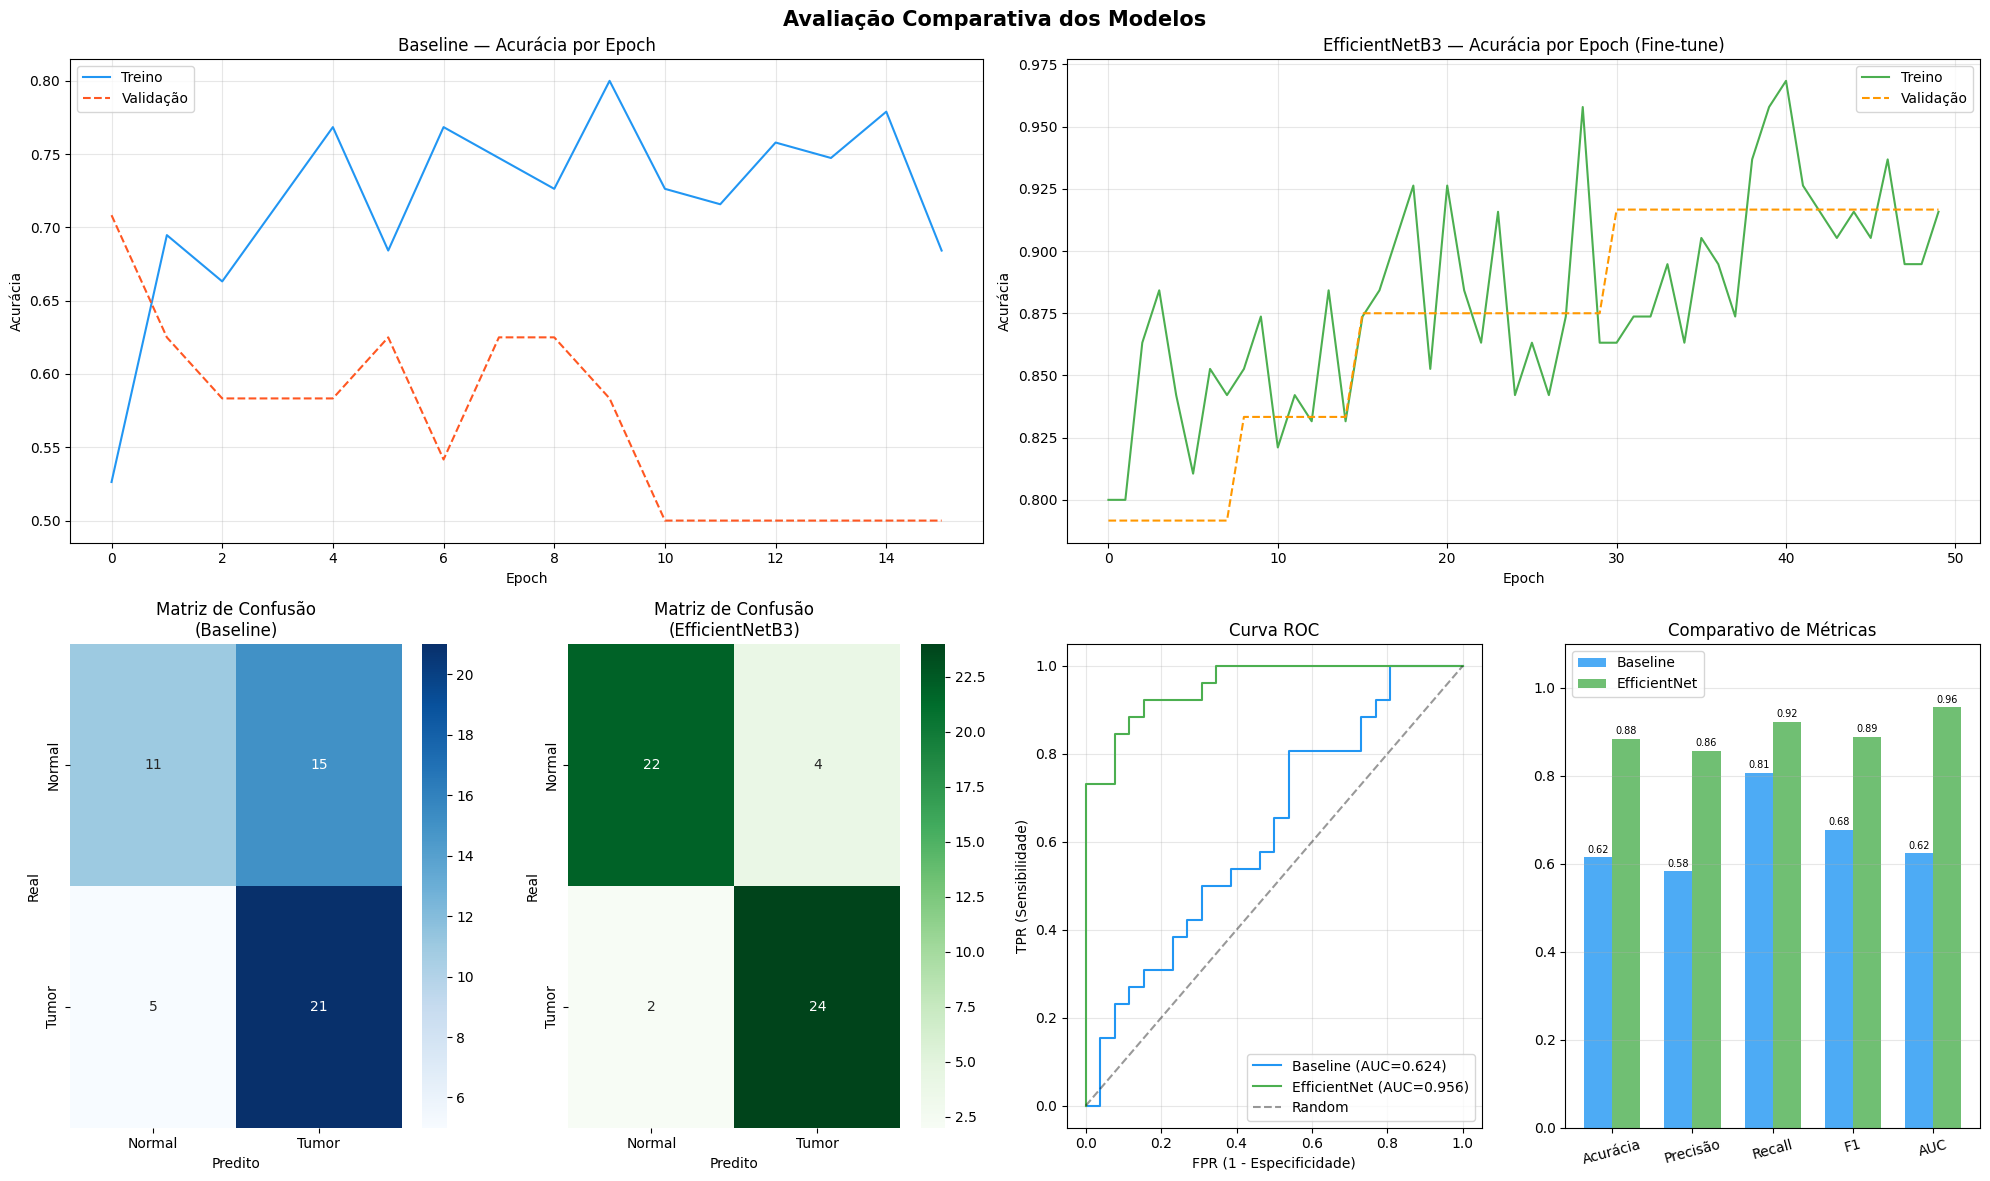

In [19]:
# ── Visualizações de avaliação ────────────────────────────────────────────────
import os
os.makedirs('/content/results', exist_ok=True)

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig)
fig.suptitle('Avaliação Comparativa dos Modelos', fontsize=15, fontweight='bold')

# --- Curvas de aprendizado (Baseline) ---
ax1 = fig.add_subplot(gs[0, 0:2])
h = history_baseline.history
ax1.plot(h['accuracy'],     label='Treino',     color='#2196F3')
ax1.plot(h['val_accuracy'], label='Validação',  color='#FF5722', linestyle='--')
ax1.set_title('Baseline — Acurácia por Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(alpha=0.3)

# --- Curvas de aprendizado (Avançado — phase 2) ---
ax2 = fig.add_subplot(gs[0, 2:4])
h2 = history_adv_phase2.history
ax2.plot(h2['accuracy'],     label='Treino',    color='#4CAF50')
ax2.plot(h2['val_accuracy'], label='Validação', color='#FF9800', linestyle='--')
ax2.set_title('EfficientNetB3 — Acurácia por Epoch (Fine-tune)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Acurácia')
ax2.legend()
ax2.grid(alpha=0.3)

# --- Matriz de confusão Baseline ---
ax3 = fig.add_subplot(gs[1, 0])
sns.heatmap(metrics_baseline['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Tumor'], yticklabels=['Normal', 'Tumor'], ax=ax3)
ax3.set_title('Matriz de Confusão\n(Baseline)')
ax3.set_ylabel('Real')
ax3.set_xlabel('Predito')

# --- Matriz de confusão Avançado ---
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(metrics_advanced['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Tumor'], yticklabels=['Normal', 'Tumor'], ax=ax4)
ax4.set_title('Matriz de Confusão\n(EfficientNetB3)')
ax4.set_ylabel('Real')
ax4.set_xlabel('Predito')

# --- Curva ROC comparativa ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(metrics_baseline['fpr'], metrics_baseline['tpr'],
         label=f'Baseline (AUC={metrics_baseline["roc_auc"]:.3f})', color='#2196F3')
ax5.plot(metrics_advanced['fpr'], metrics_advanced['tpr'],
         label=f'EfficientNet (AUC={metrics_advanced["roc_auc"]:.3f})', color='#4CAF50')
ax5.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
ax5.set_title('Curva ROC')
ax5.set_xlabel('FPR (1 - Especificidade)')
ax5.set_ylabel('TPR (Sensibilidade)')
ax5.legend()
ax5.grid(alpha=0.3)

# --- Comparativo de métricas ---
ax6 = fig.add_subplot(gs[1, 3])
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Acurácia', 'Precisão', 'Recall', 'F1', 'AUC']
x = np.arange(len(metric_names))
w = 0.35
bars1 = ax6.bar(x - w/2, [metrics_baseline[m] for m in metric_names], w,
                label='Baseline', color='#2196F3', alpha=0.8)
bars2 = ax6.bar(x + w/2, [metrics_advanced[m] for m in metric_names], w,
                label='EfficientNet', color='#4CAF50', alpha=0.8)
ax6.set_xticks(x)
ax6.set_xticklabels(metric_labels, rotation=15)
ax6.set_ylim(0, 1.1)
ax6.set_title('Comparativo de Métricas')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)
for bar in bars1: ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                            f'{bar.get_height():.2f}', ha='center', fontsize=7)
for bar in bars2: ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                            f'{bar.get_height():.2f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('/content/results/evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Interpretabilidade — Grad-CAM

**Gradient-weighted Class Activation Mapping** — visualiza quais regiões da imagem o modelo utilizou para a classificação.

> 💡 **Relevância clínica:** Permite ao radiologista validar se o modelo está analisando regiões anatomicamente plausíveis, como a área do tumor real, e não artefatos da imagem.

In [20]:
# ── Implementação manual de Grad-CAM (sem dependências externas) ──────────────
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Gera heatmap Grad-CAM para a imagem fornecida.

    Args:
        img_array: tensor (1, H, W, 3) normalizado
        model: modelo Keras treinado
        last_conv_layer_name: nome da última camada convolucional
        pred_index: classe alvo (None = classe predita)

    Returns:
        heatmap: array (H, W) com valores [0,1]
    """
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """Sobrepõe heatmap à imagem original."""
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return img, heatmap_colored, superimposed


# Encontrar última camada conv do baseline
last_conv_baseline = [l.name for l in baseline.layers
                      if 'conv' in l.name.lower()][-1]
print(f'Última camada conv (baseline): {last_conv_baseline}')


Última camada conv (baseline): conv3_1


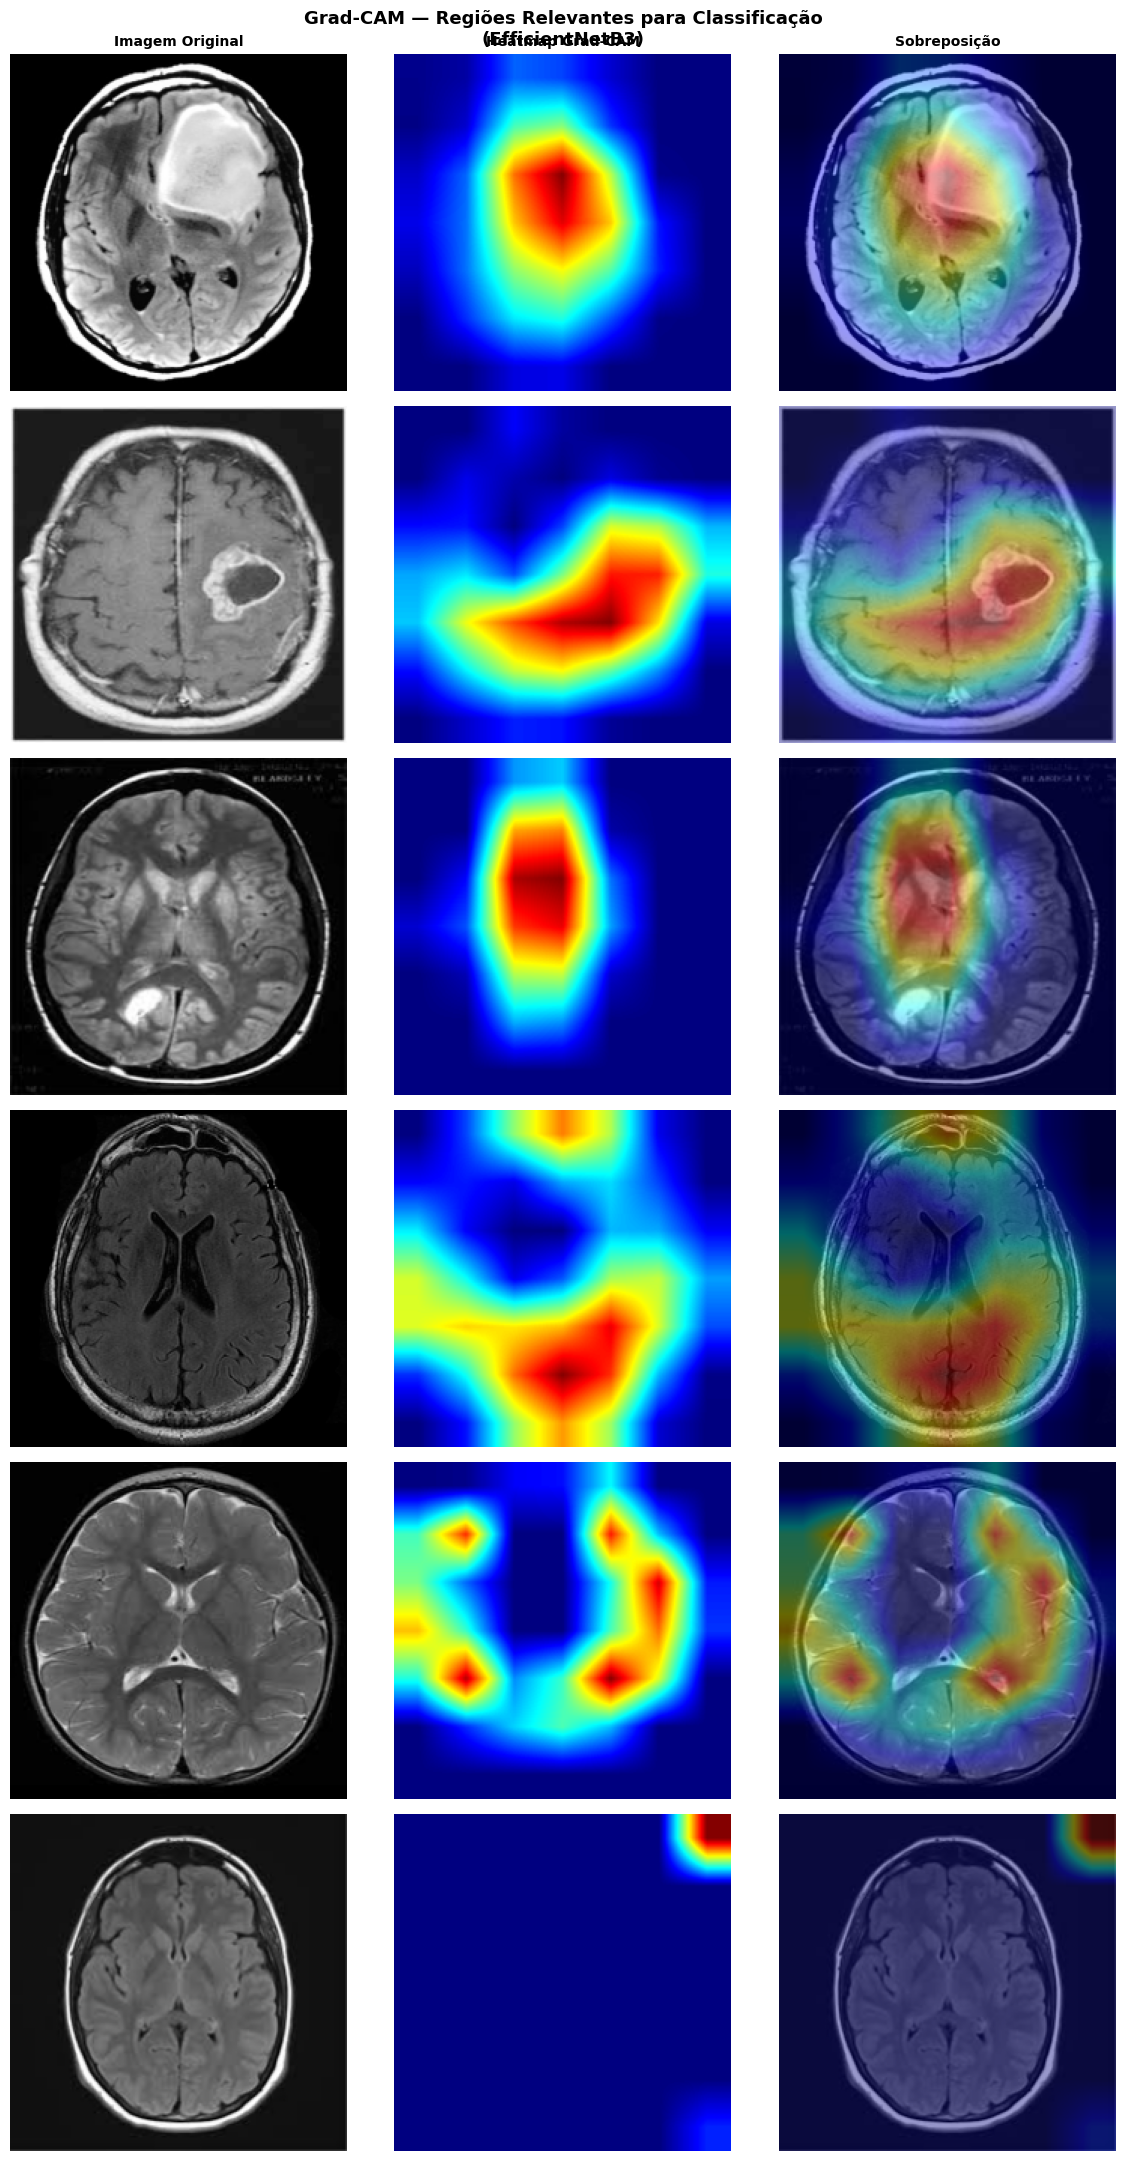


🔍 Grad-CAM: Regiões em vermelho/amarelo = maior atenção do modelo


In [21]:
# ── Visualizar Grad-CAM em amostras ──────────────────────────────────────────
os.makedirs('/content/results', exist_ok=True)

# Selecionar amostras de cada classe
tumor_samples  = df[df['label'] == 1]['path'].sample(3, random_state=SEED).values
normal_samples = df[df['label'] == 0]['path'].sample(3, random_state=SEED).values
all_samples    = list(tumor_samples) + list(normal_samples)
all_labels_s   = ['Tumor'] * 3 + ['Normal'] * 3

fig, axes = plt.subplots(6, 3, figsize=(12, 22))
fig.suptitle('Grad-CAM — Regiões Relevantes para Classificação\n(EfficientNetB3)',
             fontsize=13, fontweight='bold')
cols = ['Imagem Original', 'Heatmap Grad-CAM', 'Sobreposição']
for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontweight='bold', fontsize=10)

for i, (path, true_label) in enumerate(zip(all_samples, all_labels_s)):
    # Preprocessar
    img_arr, _ = load_and_preprocess(path, 0, augment=False)
    img_arr = tf.expand_dims(img_arr, 0)

    # Predição
    pred_prob = advanced.predict(img_arr, verbose=0)[0][0]
    pred_label = 'Tumor' if pred_prob >= 0.5 else 'Normal'
    correct = '✓' if pred_label == true_label else '✗'

    # Grad-CAM
    try:
        last_conv = [l.name for l in advanced.layers
                     if 'conv' in l.name.lower() and 'bn' not in l.name.lower()][-1]
        heatmap = make_gradcam_heatmap(img_arr, advanced, last_conv)
        orig, hmap, overlay = overlay_gradcam(path, heatmap)
    except Exception as e:
        # Fallback: usar imagem sem grad-cam
        orig = cv2.cvtColor(cv2.resize(cv2.imread(path), (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)
        hmap = np.zeros_like(orig)
        overlay = orig

    color = '#4CAF50' if correct == '✓' else '#F44336'
    axes[i, 0].imshow(orig)
    axes[i, 0].set_ylabel(f'{true_label}\n{correct} ({pred_prob:.2f})',
                           color=color, fontsize=9)
    axes[i, 1].imshow(hmap)
    axes[i, 2].imshow(overlay)

    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig('/content/results/gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n🔍 Grad-CAM: Regiões em vermelho/amarelo = maior atenção do modelo')


## 9. Discussão Clínica e Limitações

### Como interpretar os resultados para uso clínico

| Métrica | Significado Clínico |
|---------|--------------------|
| **Recall (Sensibilidade)** | Capacidade de detectar tumores existentes — falsos negativos são graves |
| **Precisão** | Dos casos classificados como tumor, quantos são reais — evita biópsias desnecessárias |
| **ROC-AUC** | Performance geral do modelo independente do threshold |
| **Grad-CAM** | Região de atenção — deve coincidir com área radiologicamente suspeita |

### ⚠️ Limitações Críticas

1. **Dataset pequeno e não representativo** — poucos casos de MRI cedidos publicamente
2. **Sem metadados clínicos** — idade, sexo, tipo histológico do tumor não são considerados
3. **Distribuição de domínio** — equipamentos MRI diferentes produzem artefatos distintos
4. **Classificação binária simplificada** — tumor é heterogêneo (glioma, meningioma, etc.)
5. **Ausência de validação prospectiva** — métricas são retrospectivas no mesmo dataset

### Sugestões de Validação com Especialista

1. **Estudo piloto**: submeter 50 casos ao modelo E a um radiologista cegamente
2. **Análise de concordância** via Kappa de Cohen
3. **Revisão dos Grad-CAMs** por neurologista para verificar plausibilidade anatômica
4. **Calibração do threshold** conforme tolerância clínica ao falso negativo
5. **Registro em plataforma de IA médica** (ANVISA, FDA 510k) para uso clínico real


In [22]:
# ── Tabela de comparação final ────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Modelo':    ['CNN Baseline', 'EfficientNetB3 (TL)'],
    'Acurácia':  [metrics_baseline['accuracy'],  metrics_advanced['accuracy']],
    'Precisão':  [metrics_baseline['precision'], metrics_advanced['precision']],
    'Recall':    [metrics_baseline['recall'],    metrics_advanced['recall']],
    'F1-Score':  [metrics_baseline['f1'],        metrics_advanced['f1']],
    'ROC-AUC':   [metrics_baseline['roc_auc'],   metrics_advanced['roc_auc']],
}).set_index('Modelo')

comparison_df = comparison_df.applymap(lambda x: f'{x:.4f}')
print('\n📋 COMPARATIVO FINAL')
print('=' * 70)
print(comparison_df.to_string())

# Salvar
comparison_df.to_csv('/content/results/model_comparison.csv')
print('\nResultados salvos em /content/results/model_comparison.csv')



📋 COMPARATIVO FINAL
                    Acurácia Precisão  Recall F1-Score ROC-AUC
Modelo                                                        
CNN Baseline          0.6154   0.5833  0.8077   0.6774  0.6243
EfficientNetB3 (TL)   0.8846   0.8571  0.9231   0.8889  0.9556

Resultados salvos em /content/results/model_comparison.csv


In [23]:
# ── Salvar modelos finais ─────────────────────────────────────────────────────
baseline.save('/content/models/baseline_cnn_final.h5')
advanced.save('/content/models/efficientnet_b3_final.h5')

print('✅ Modelos salvos:')
print('   /content/models/baseline_cnn_final.h5')
print('   /content/models/efficientnet_b3_final.h5')
print()
print('📁 Para fazer download, execute:')
print('   from google.colab import files')
print('   files.download("/content/models/efficientnet_b3_final.h5")')


✅ Modelos salvos:
   /content/models/baseline_cnn_final.h5
   /content/models/efficientnet_b3_final.h5

📁 Para fazer download, execute:
   from google.colab import files
   files.download("/content/models/efficientnet_b3_final.h5")
